Задание:
1. Выбрать бизнес-цель для набора данных по Вашему варианту задания для решения задачи кластеризации.
2. Выполнить понижение размерности и визуализацию данных.
3. Выполнить выбор количества кластеров на основе оценки инерции и коэффициента силуэта.
4. Выполнить кластерный анализ с применением иерархического и неиерархического алгоритма кластеризации.
5. Оценить качество решения.

Бизнес-цель

Автоматически группировать отзывы о медицинских услугах по тематике (о клинике, о докторе, об услуге) и эмоциональной окраске (позитивный/негативный). 

Это поможет:
1. выявлять частые проблемы в конкретных аспектах (например, негатив о клинике),
2. автоматически маркировать новые отзывы,
3. использовать результаты для внутренней аналитики и улучшения сервиса.

Шаг 1: Подготовка данных и векторизация
1. Загружаем clean_review,
2. Векторизуем его с помощью TF-IDF,
3. Формируем категориальные метки (aspect_sentiment) для дальнейшего анализа.

In [34]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
import nltk

nltk.download("stopwords")
russian_stopwords = stopwords.words("russian")

# Загрузка данных
df = pd.read_csv("data/finally_dataset.csv")
df = df.dropna(subset=["clean_review"])

# Комбинированная метка: тематика + тональность
def get_aspect(row):
    if row["clinic"] == 1:
        return "clinic"
    elif row["doctor"] == 1:
        return "doctor"
    elif row["service"] == 1:
        return "service"
    else:
        return "unknown"

df["aspect"] = df.apply(get_aspect, axis=1)
df["aspect_sentiment"] = df["aspect"] + "_" + df["predicted_sentiment"].str.lower()

# Векторизация текстов
vectorizer = TfidfVectorizer(stop_words=russian_stopwords, max_features=1000)
X_tfidf = vectorizer.fit_transform(df["clean_review"])

print("Векторизация завершена. Размерность признаков:", X_tfidf.shape)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/a.makienko/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Векторизация завершена. Размерность признаков: (7571, 1000)


Визуализация данных с помощью TSNE

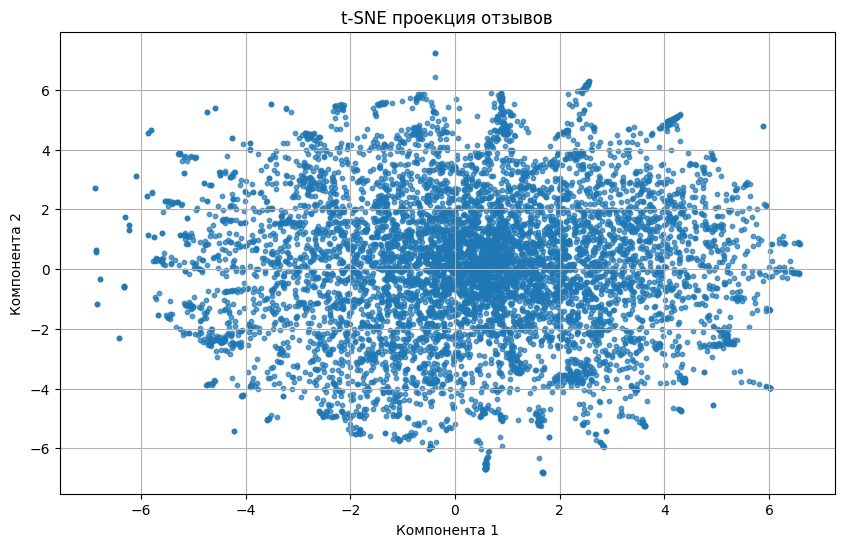

In [35]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, perplexity=10, learning_rate=300, max_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_tfidf.toarray())

plt.figure(figsize=(10, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], s=10, alpha=0.7)
plt.title("t-SNE проекция отзывов")
plt.xlabel("Компонента 1")
plt.ylabel("Компонента 2")
plt.grid(True)
plt.show()


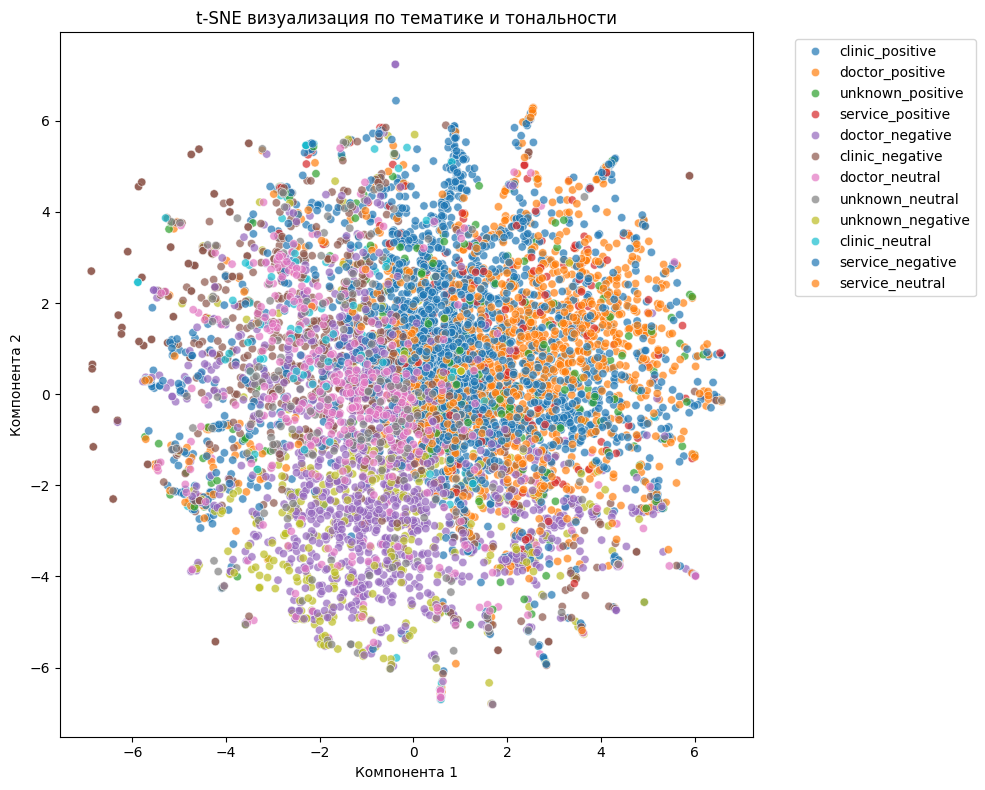

In [36]:
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=df["aspect_sentiment"], palette="tab10", alpha=0.7)
plt.title("t-SNE визуализация по тематике и тональности")
plt.xlabel("Компонента 1")
plt.ylabel("Компонента 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Теперь переходим к следующему шагу — выбору оптимального количества кластеров. Для этого мы используем:
1. Инерцию (метод локтя) — показывает, насколько хорошо объекты внутри кластера схожи друг с другом.
2. Коэффициент силуэта — измеряет, насколько хорошо объект вписывается в свой кластер по сравнению с соседними.

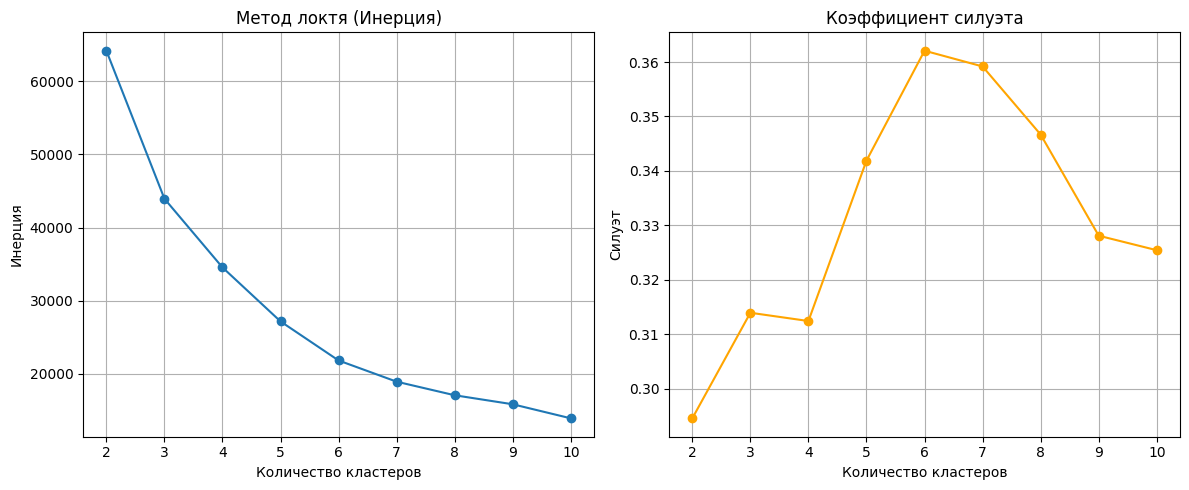

In [37]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    kmeans.fit(X_tsne)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_tsne, kmeans.labels_))

# Визуализация метрик
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, inertias, marker='o')
plt.title("Метод локтя (Инерция)")
plt.xlabel("Количество кластеров")
plt.ylabel("Инерция")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='o', color='orange')
plt.title("Коэффициент силуэта")
plt.xlabel("Количество кластеров")
plt.ylabel("Силуэт")
plt.grid(True)

plt.tight_layout()
plt.show()

Кластеризация
1. KMeans (неиерархическая кластеризация): KMeans — это алгоритм, который делит данные на k кластеров, минимизируя внутрикластерную инерцию.
2. Иерархическая кластеризация: В отличие от KMeans, иерархическая кластеризация не требует заранее заданного количества кластеров. Она строит дендрограмму (дерево) и позволяет исследовать различные уровни кластеризации.

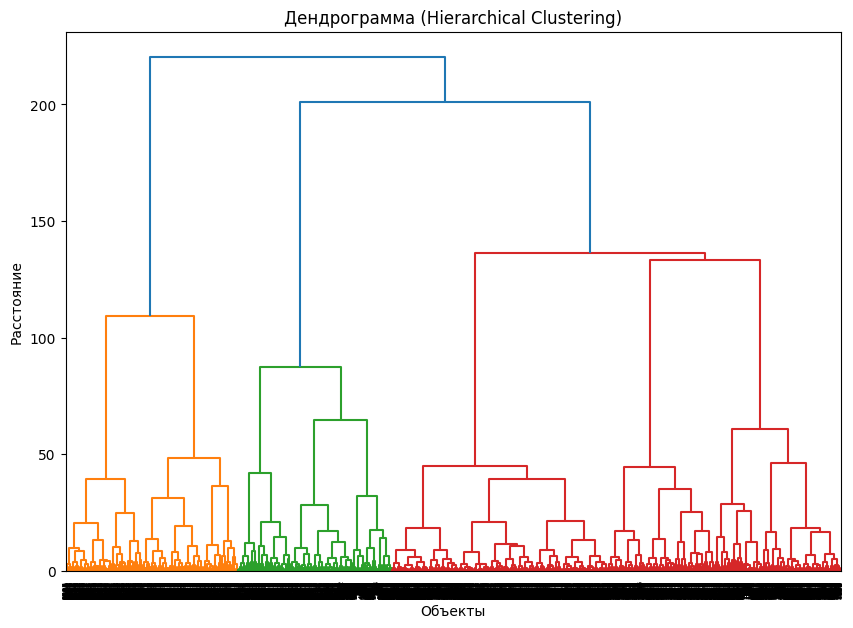

In [40]:
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage

# KMeans кластеризация с оптимальным количеством кластеров
kmeans = KMeans(n_clusters=6, random_state=42)
labels = kmeans.fit_predict(X_tsne)

# Визуализируем дендрограмму для иерархической кластеризации
linked = linkage(X_tsne, 'ward')

plt.figure(figsize=(10, 7))
dendrogram(linked)
plt.title('Дендрограмма (Hierarchical Clustering)')
plt.xlabel('Объекты')
plt.ylabel('Расстояние')
plt.show()


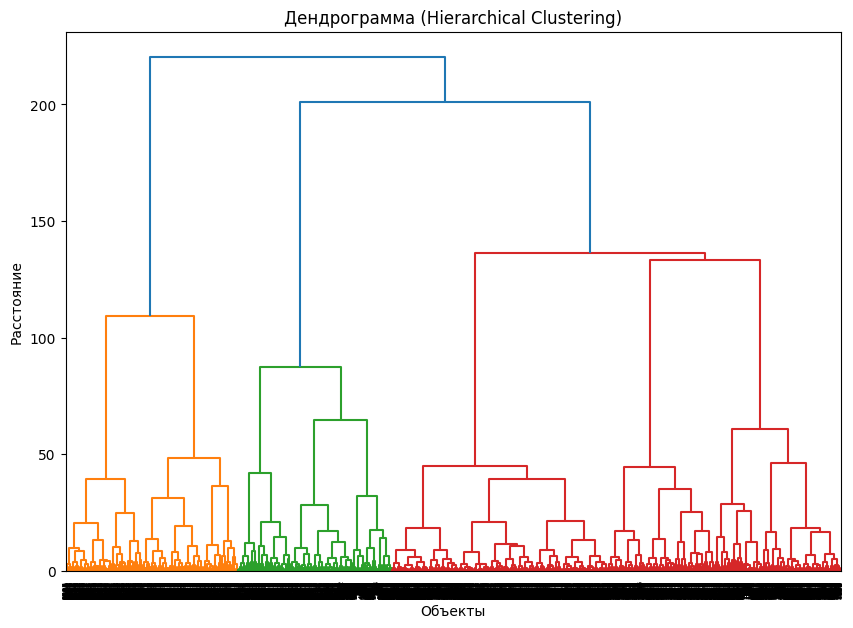

In [ ]:
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage

# KMeans кластеризация с оптимальным количеством кластеров
kmeans = KMeans(n_clusters=6, random_state=42)
labels = kmeans.fit_predict(X_tsne)

# Визуализируем дендрограмму для иерархической кластеризации
linked = linkage(X_tsne, 'ward')

plt.figure(figsize=(10, 7))
dendrogram(linked)
plt.title('Дендрограмма (Hierarchical Clustering)')
plt.xlabel('Объекты')
plt.ylabel('Расстояние')
plt.show()


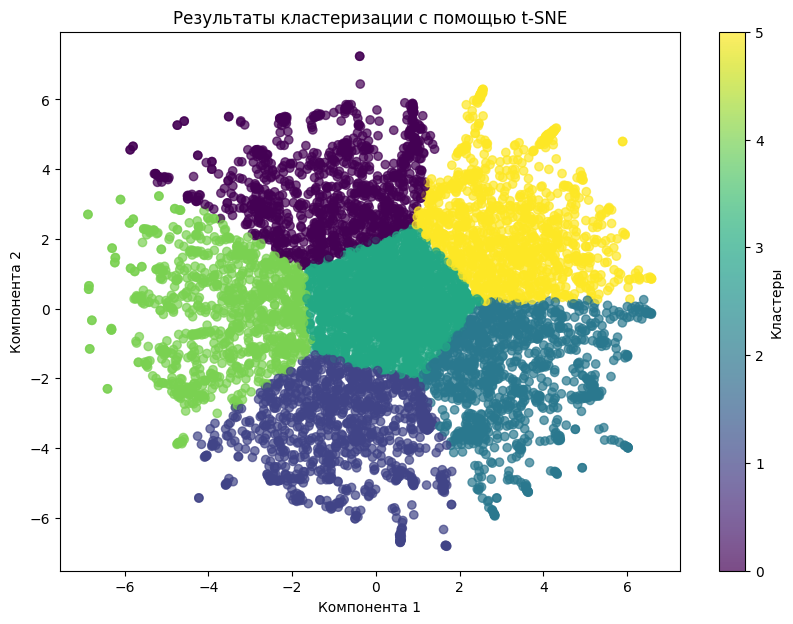

In [41]:
# Визуализируем результаты кластеризации с помощью t-SNE
plt.figure(figsize=(10, 7))

# Цвета для разных кластеров
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='viridis', marker='o', alpha=0.7)

# Добавим метки осей
plt.title('Результаты кластеризации с помощью t-SNE')
plt.xlabel('Компонента 1')
plt.ylabel('Компонента 2')

# Легенда
plt.colorbar(label='Кластеры')
plt.show()